In [230]:
"""Settings related to escape pattern analysis."""
Path = r'Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\replay\replay_SS_decoder\SSdecoder_78ef7edd63fa4bfc_data.npz'


In [185]:
"""Imports"""
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import zscore
np.warnings = warnings
from replay_trajectory_classification import SortedSpikesDecoder, Environment, RandomWalk, estimate_movement_var

In [231]:
"""Load data and set paths"""
settings_file = Path.replace('_data.npz', '_settings.npz')
save_file = Path.replace('_data.npz', '_results.npz')
database_path = "\\".join(Path.split('\\')[:-1]) + "\\replay_results.csv"
database = pd.read_csv(database_path)
hexname = Path.split("\\")[-1].split("_")[1]
# find row in database corresponding to this run
database_row = database[database['name'] == hexname]

data = np.load(Path, allow_pickle=True)
settings = np.load(settings_file, allow_pickle=True)

database_row

,name,replay_cells,replay_search_window,replay_decoder_variable,replay_train_condition,replay_test_condition,replay_decoder_train_time_period,replay_decoder_test_time_period,replay_rank_order_corr_method,replay_occupancy_prior,...,replay_state_space_decoder_bin_size,stim_type,redo_compute,cluster_type,show_plots,condition_types,compartment_split,parallel_pool_linshit,replay_template_variable,data_vars
1,78ef7edd63fa4bfc,all,500,2D_position,barrier_pre_flip,barrier_pre_flip,correct_long_homing&escape,error_homing&escape,first_activity,uniform,...,0.001,audio,True,good,False,experimental_conditions,['all'],True,escape,"['train_spikes', 'train_time', 'train_mask', '..."


In [ ]:
# set up parameters for decoder
sampling_frequency = 1000 / settings['replay_state_space_decoder_bin_size'] # in Hz, bin_width is in ms
test_position_onsets = np.concatenate((np.array([0]), np.where(np.diff(data['test_segments']) == 1)[0]+1))[:-1]
test_position_offsets = np.concatenate((test_position_onsets[1:], [len(data['test_segments'])-1]))
train_position_onsets = np.concatenate((np.array([0]), np.where(np.diff(data['train_segments']) == 1)[0]+1))[:-1]
train_position_offsets = np.concatenate((train_position_onsets[1:], [len(data['train_segments'])-1]))

# set up environment parameters
nbins = np.unique(data['train_position'])
linear_track_env = Environment(
                            place_bin_size=1,  # For binned data use 1, Adjust based on your actual bin size
                            # track_graph=my_linear_graph,  # Define a linear graph with 25 nodes
                            edge_order=[(i, i + 1) for i in range(int(max(nbins)))],  # Sequential edges
                            edge_spacing=None,  # No gaps between edges
                            position_range=[(0, len(nbins))],  # 0 to 100% of escape route
                            infer_track_interior=False,  # Data is already binned
                            fill_holes=False,
                            dilate=False,
                            bin_count_threshold=1,
                        )

transition_type = RandomWalk(movement_var=1)

decoder = SortedSpikesDecoder(
                            environment=linear_track_env,
                            transition_type=transition_type,
                            sorted_spikes_algorithm='spiking_likelihood_kde',
                            sorted_spikes_algorithm_params={'block_size': None,
                                                            'position_std': [1.0],
                                                            'use_diffusion': False},
                        )

"""train on a single run!"""
# decoder.fit(data['train_position'][train_position_onsets[2]:train_position_offsets[2]], data['train_spikes'][train_position_onsets[2]:train_position_offsets[2],:])
"""remove first 500ms from each homing for training"""
# train_s = np.empty((0, data['train_spikes'].shape[1]))
# train_p = np.array([])
# for on, off in zip(train_position_onsets, train_position_offsets):
#     train_s = np.concatenate((train_s, data['train_spikes'][on + 200:off,:])) 
#     train_p = np.concatenate((train_p, data['train_position'][on + 200:off])) 
# decoder.fit(train_p, train_s)
"""plain vanilla use of trianing data"""
decoder.fit(data['train_position'], data['train_spikes'])

test_time = np.arange(0, data['test_time'].shape[0] / (1 / 0.001), 0.001)
test_results = decoder.predict(data['test_spikes'], time=test_time)
test_res = np.array(test_results.causal_posterior)
test_predicted = np.sum(test_res.T * np.arange(test_res.shape[1])[:, None], axis=0) / np.sum(test_res.T, axis=0)

train_time = np.arange(0, data['train_time'].shape[0] / (1 / 0.001), 0.001)
train_results = decoder.predict(data['train_spikes'], time=train_time)
train_res = np.array(train_results.causal_posterior)
train_predicted = np.sum(train_res.T * np.arange(train_res.shape[1])[:, None], axis=0) / np.sum(train_res.T, axis=0)

"""Compute RMSE for train and test data predictions"""

# test data

test_rmse = np.zeros(len(test_position_onsets))
for idx in range(len(test_position_onsets)):
    mse = np.mean((data['test_position'][test_position_onsets[idx]:test_position_offsets[idx]] - 
                    np.argmax(test_res[test_position_onsets[idx]:test_position_offsets[idx], :].T, axis=0))**2)
    test_rmse[idx] = np.sqrt(mse)

# train_data

train_rmse = np.zeros(len(train_position_onsets))
for idx in range(len(train_position_onsets)):
    mse = np.mean((data['train_position'][train_position_onsets[idx]:train_position_offsets[idx]] - 
                    np.argmax(train_res[train_position_onsets[idx]:train_position_offsets[idx], :].T, axis=0))**2)
    train_rmse[idx] = np.sqrt(mse)

bins = np.arange(0, max(max(train_rmse), max(test_rmse)) + 1, 2)

fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.hist(train_rmse, bins = bins, alpha=0.5, label='Train RMSE')
axs.hist(test_rmse, bins = bins, alpha=0.5, label='Test RMSE')
axs.set_xlabel('RMSE')
axs.set_ylabel('Homing number')
axs.legend()

# save results

np.savez(save_file,
         test_causal_posterior=test_results.causal_posterior,
         test_acausal_posterior=test_results.acausal_posterior,
         train_causal_posterior=train_results.causal_posterior,
         train_acausal_posterior=train_results.acausal_posterior)

ValueError: range argument must have one entry per dimension

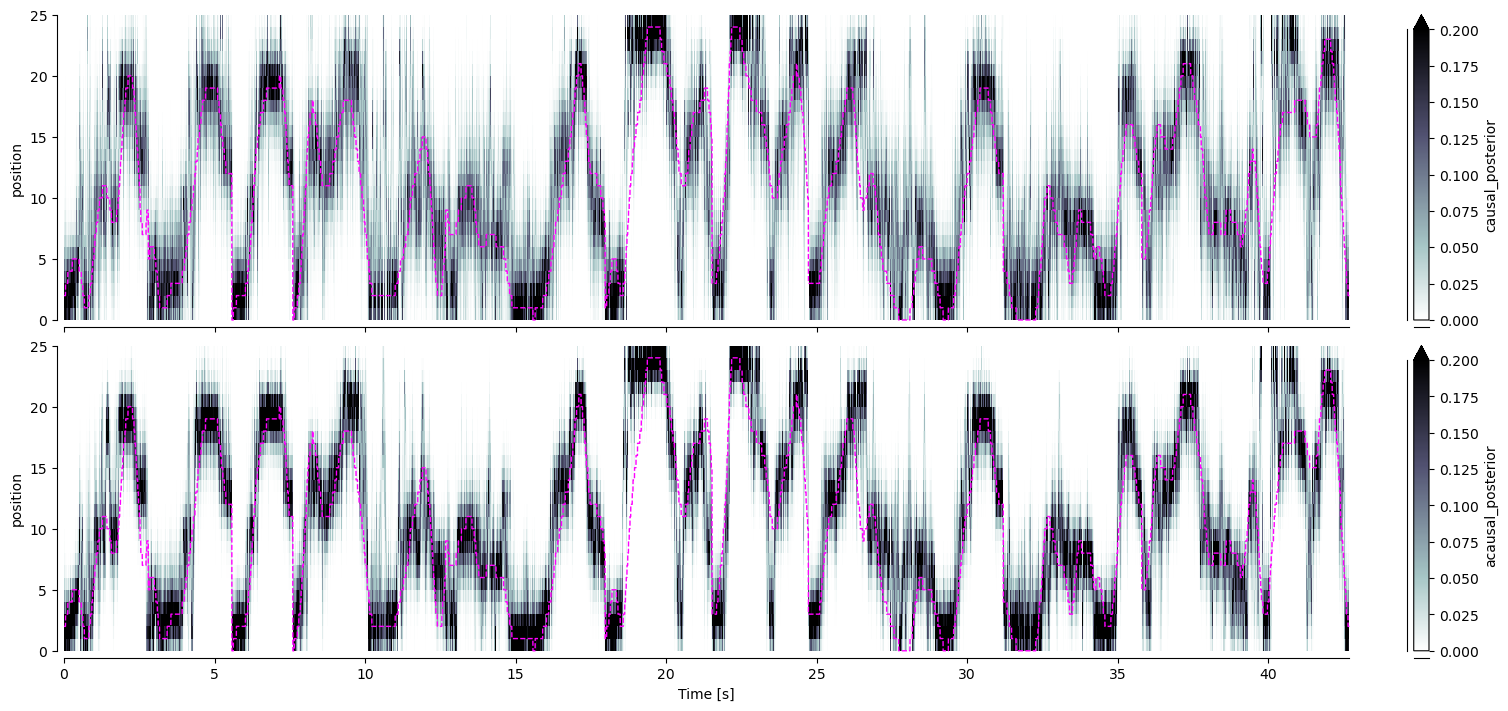

In [211]:
"""Plot train data predictions from decoder"""
# use only either causal or acausal posterior for plotting
# also plot the actual run trajectory?

# fig, axs = plt.subplots(3, 1, sharex=True, constrained_layout=True, figsize=(15, 7))

# spike_time_ind, neuron_ind = np.nonzero(data['train_spikes'])
# ax0 = axs[0]
# ax0.scatter(data['train_time'][spike_time_ind], neuron_ind, color='black', s=.2, alpha = .2, zorder = 1)
# ax0.set_yticks((0, data['train_spikes'].shape[1]))
# ax0.set_ylabel('Neuron Index')

fig,axs = plt.subplots(2, 1, sharex=True, constrained_layout=True, figsize=(15, 7))
axes = axs[-2]
train_results.causal_posterior.plot(x="time", y="position", ax=axes, cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes.plot(train_time, data['train_position'], color="magenta", linestyle="--", linewidth=1, clip_on=False)
axes.set_xlabel("")

axes = axs[-1]
train_results.acausal_posterior.plot(x="time", y="position", ax=axes, cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes.plot(train_time, data['train_position'], color="magenta", linestyle="--", linewidth=1, clip_on=False)
axes.set_xlabel('Time [s]')

sns.despine(offset=5)

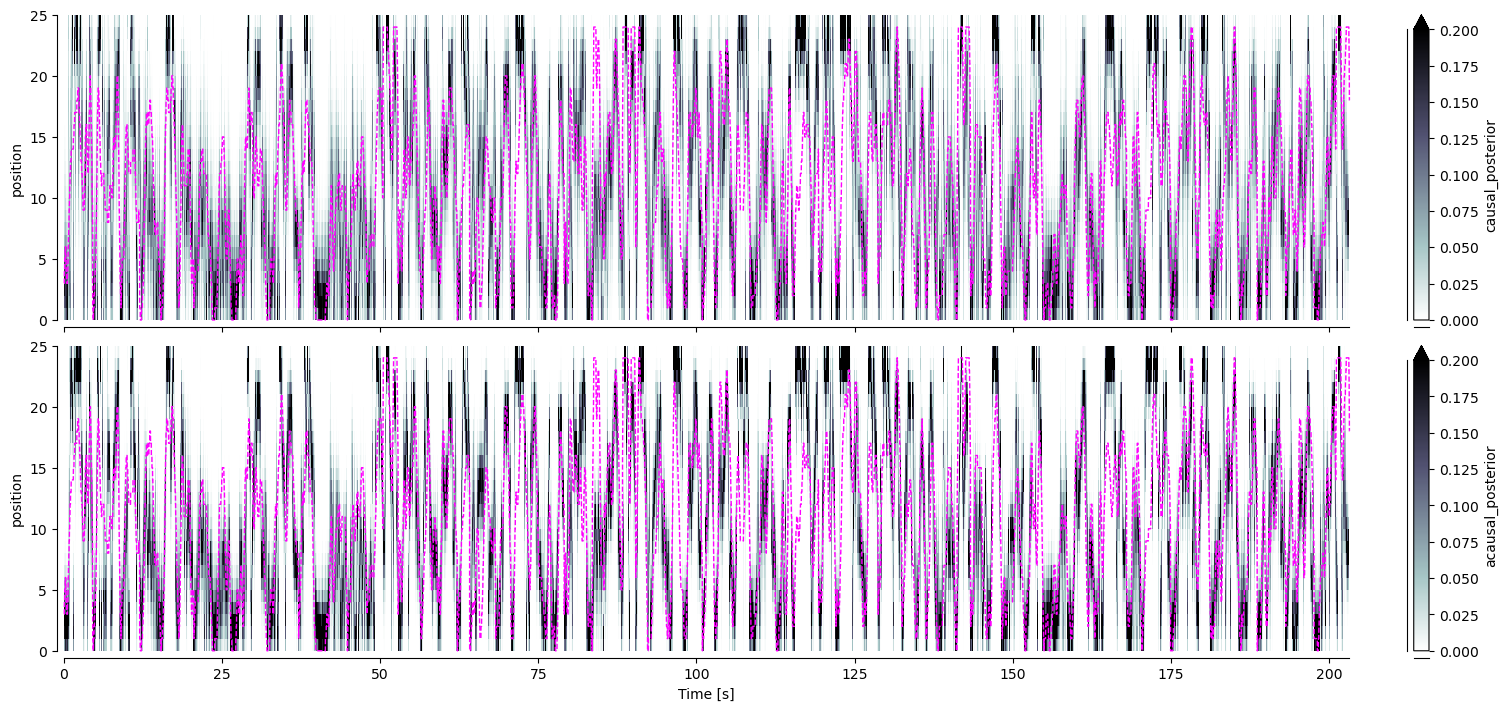

In [212]:
"""Plot test data predictions from decoder"""
# use only either causal or acausal posterior for plotting
# also plot the actual run trajectory?

# fig, axs = plt.subplots(3, 1, sharex=True, constrained_layout=True, figsize=(15, 7))

# spike_time_ind, neuron_ind = np.nonzero(data['test_spikes'])
# ax0 = axs[0]
# ax0.scatter(data['test_time'][spike_time_ind], neuron_ind, color='black', s=.2, alpha = .2, zorder = 1)
# ax0.set_yticks((0, data['test_spikes'].shape[1]))
# ax0.set_ylabel('Neuron Index')

fig,axs = plt.subplots(2, 1, sharex=True, constrained_layout=True, figsize=(15, 7))
axes = axs[-2]
test_results.causal_posterior.plot(x="time", y="position", ax=axes, cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes.plot(test_time, data['test_position'], color="magenta", linestyle="--", linewidth=1, clip_on=False)
axes.set_xlabel("")

axes = axs[-1]
test_results.acausal_posterior.plot(x="time", y="position", ax=axes, cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes.plot(test_time, data['test_position'], color="magenta", linestyle="--", linewidth=1, clip_on=False)
axes.set_xlabel('Time [s]')

sns.despine(offset=5)

In [213]:
# load behavior data, filter with test mask, plot the trjectories and see what the mouse was actually doing!
import pandas as pd
video_path = Path.split("models")[0] + "full_video_dataframe.csv"
# vdf = pd.read_csv(video_path)
test_frame_onsets = np.where(np.diff(data['test_mask'].astype(int))>0)[0] + 1
test_frame_offsets = np.where(np.diff(data['test_mask'].astype(int))<0)[0] + 1
train_frame_onsets = np.where(np.diff(data['train_mask'].astype(int))>0)[0] + 1
train_frame_offsets = np.where(np.diff(data['train_mask'].astype(int))<0)[0] + 1

def trajectory_plot(axs, x, y, condition, barrier = []):
    axs.scatter(x, y, s=1, color='b', alpha = 0.2)
    circle = plt.Circle((512, 512), 460, color='k', fill=False, linewidth=2)
    axs.add_patch(circle)
    if condition != 'shelter_only':
        if barrier[0] < 512:
            axs.plot([barrier[0],512+460], [512,512], 'k', linewidth=2)
        elif barrier[0] > 512:
            axs.plot([512-460, barrier[0]], [512,512], 'k', linewidth=2)

    # Add red transparent square
    square = patches.Rectangle((437, 886), 150, 90, color='r', alpha=0.4)
    axs.add_patch(square)
    axs.set_xlim(0, 1024)
    axs.set_ylim(0, 1024)
    axs.set_xticks([])
    axs.set_yticks([])
    axs.set_frame_on(False)
    axs.set_aspect('equal')
    axs.invert_yaxis()

def gaussian_smooth_rates(
    spikes,
    sigma_ms=20,
    bin_ms=1.0,
    edge_mode="reflect",   # "reflect" or "trim"
    trim_sigma=3.0         # trim = trim_sigma * sigma
):
    """
    Smooth binned spikes (time x neurons) with a Gaussian kernel.
    
    Parameters
    ----------
    spikes : array (T x N)
        Binary or count matrix (1 ms bins by default).
    sigma_ms : float
        Gaussian std dev in ms.
    bin_ms : float
        Bin size in ms.
    edge_mode : str
        "reflect" or "trim".
    trim_sigma : float
        Number of sigmas to trim at each edge if edge_mode="trim".
    
    Returns
    -------
    rates : array
        Smoothed firing rates in Hz.
    """
    spikes = np.asarray(spikes)
    sigma_bins = sigma_ms / bin_ms
    
    # Build Gaussian kernel (±3σ by default)
    half_width = int(np.ceil(3 * sigma_bins))
    x = np.arange(-half_width, half_width + 1)
    kernel = np.exp(-0.5 * (x / sigma_bins) ** 2)
    kernel /= kernel.sum()

    # Convolve along time for each neuron
    if edge_mode == "reflect":
        pad = half_width
        padded = np.pad(spikes, ((pad, pad), (0, 0)), mode="reflect")
        smoothed = np.apply_along_axis(lambda m: np.convolve(m, kernel, mode="valid"), 0, padded)
    elif edge_mode == "trim":
        smoothed = np.apply_along_axis(lambda m: np.convolve(m, kernel, mode="same"), 0, spikes)
        trim = int(np.ceil(trim_sigma * sigma_bins))
        if trim > 0:
            smoothed = smoothed[trim:-trim, :]
    else:
        raise ValueError("edge_mode must be 'reflect' or 'trim'")

    # Convert to Hz
    rates = smoothed * (1000.0 / bin_ms)
    return rates

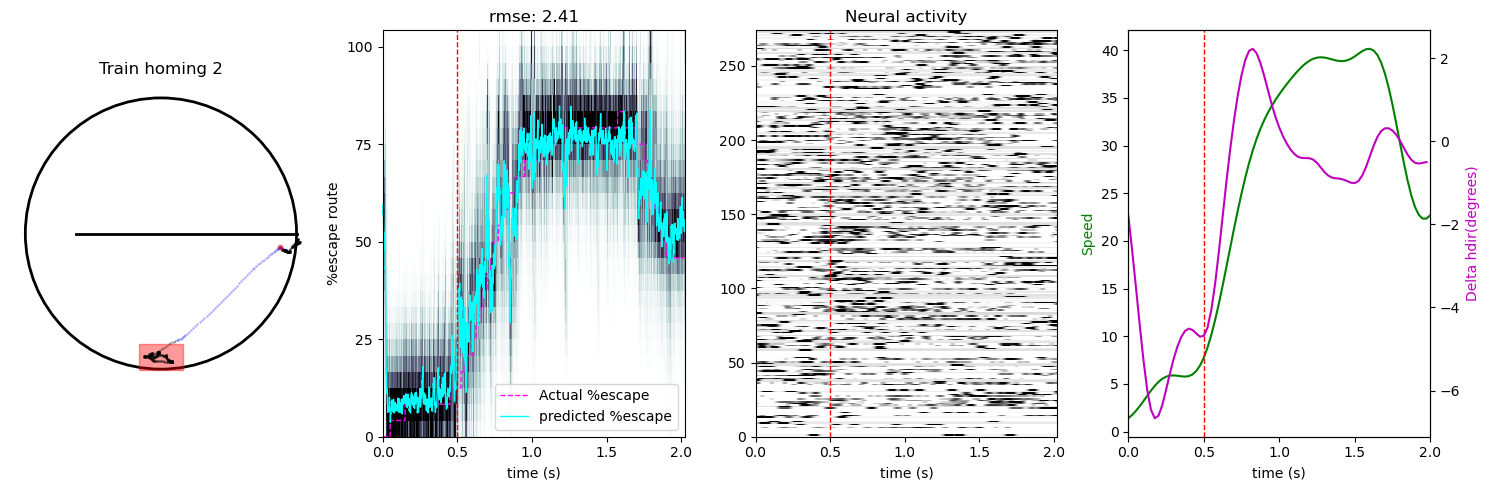

In [ ]:
"""Plot for individual train data homings!
Compare behavior to the actual and decoder-predicted fraction of escape route!"""
idx = 2
time_marker = .5

fig, ax = plt.subplots(1, 4, figsize = (15, 5))
axs = ax[0]
trajectory_plot(axs, vdf['mouse_x_position'].to_numpy()[train_frame_onsets[idx]:train_frame_offsets[idx]],
                vdf['mouse_y_position'].to_numpy()[train_frame_onsets[idx]:train_frame_offsets[idx]], settings['replay_train_condition'], settings['barrier_train_location'])
axs.scatter(vdf['mouse_x_position'].to_numpy()[train_frame_offsets[idx]:train_frame_offsets[idx]+400],
            vdf['mouse_y_position'].to_numpy()[train_frame_offsets[idx]:train_frame_offsets[idx]+400], s=1, color='k', alpha = 0.2) # to show where the mouse went after the homing period
axs.scatter(vdf['mouse_x_position'].to_numpy()[train_frame_onsets[idx]-200:train_frame_onsets[idx]],
            vdf['mouse_y_position'].to_numpy()[train_frame_onsets[idx]-200:train_frame_onsets[idx]], s=1, color='k', alpha = 0.2) # to show where the mouse went after the homing period
axs.scatter(vdf['mouse_x_position'].to_numpy()[train_frame_onsets[idx]+int(40*time_marker)],
            vdf['mouse_y_position'].to_numpy()[train_frame_onsets[idx]+int(40*time_marker)], s=10, color='r', alpha = 0.5) # to show where the mouse went after the homing period
axs.set_title(f"Train homing {idx}")

axs = ax[1]
train_time_slice = train_time[train_position_onsets[idx]:train_position_offsets[idx]] - train_time[train_position_onsets[idx]]
axs.imshow(train_res[train_position_onsets[idx]:train_position_offsets[idx], :].T, aspect='auto', origin='lower', cmap='bone_r', vmin=0, vmax=.2,
           extent=[train_time_slice[0], train_time_slice[-1], 0, train_res.shape[1]], interpolation='none')
axs.plot(train_time_slice, 
         train_predicted[train_position_onsets[idx]:train_position_offsets[idx]], color="cyan", linestyle="-", linewidth=1, clip_on=False,
         label = r"predicted %escape")
axs.plot(train_time_slice, # so that it starts at 0! 
         data['train_position'][train_position_onsets[idx]:train_position_offsets[idx]], color="magenta", linestyle="--", linewidth=1, clip_on=False,
         label = r"Actual %escape")
axs.axvline(x=time_marker, color='r', linestyle='--', linewidth=1)
axs.set_ylabel(r'%escape route')
axs.set_yticks(np.arange(0, train_res.shape[1]+1,train_res.shape[1]//4))
axs.set_yticklabels(np.arange(0, 101, 25))
axs.set_xlabel('time (s)')
axs.set_title(f"rmse: {train_rmse[idx]:.2f}")
axs.legend(loc='lower right')

axs = ax[2]
rates = gaussian_smooth_rates(data['train_spikes'][train_position_onsets[idx]:train_position_offsets[idx], data['template_seq']],
                              sigma_ms=20, bin_ms=1.0, edge_mode="trim", trim_sigma=3.0,)
z_rates = zscore(rates, axis=0)
axs.imshow(z_rates.T, aspect='auto', origin='lower', cmap='gray_r', vmin = -.5, vmax = 2,
           extent=[train_time_slice[0], train_time_slice[-1], 0, data['train_spikes'].shape[1]], interpolation='none')
axs.axvline(x=time_marker, color='r', linestyle='--', linewidth=1)
axs.set_xlabel('time (s)')
axs.set_title('Neural activity')

axs = ax[3]
time = np.arange(len(vdf['hdir'].to_numpy()[train_frame_onsets[idx]:train_frame_offsets[idx]])) / 40
axs.plot(time, vdf['speed'].to_numpy()[train_frame_onsets[idx]:train_frame_offsets[idx]], color='g') 
axs.axvline(x=time_marker, color='r', linestyle='--', linewidth=1) 
axs.set_xlabel('time (s)') 
axs.set_ylabel('Speed', color = 'g') 
axs.set_xlim(0, time[-1])
axs2 = axs.twinx()
axs2.plot(time[:-1], np.diff(np.rad2deg(vdf['hdir'].to_numpy()[train_frame_onsets[idx]:train_frame_offsets[idx]])), color='m')
axs2.set_ylabel('Delta hdir(degrees)', color='m')

fig.tight_layout()

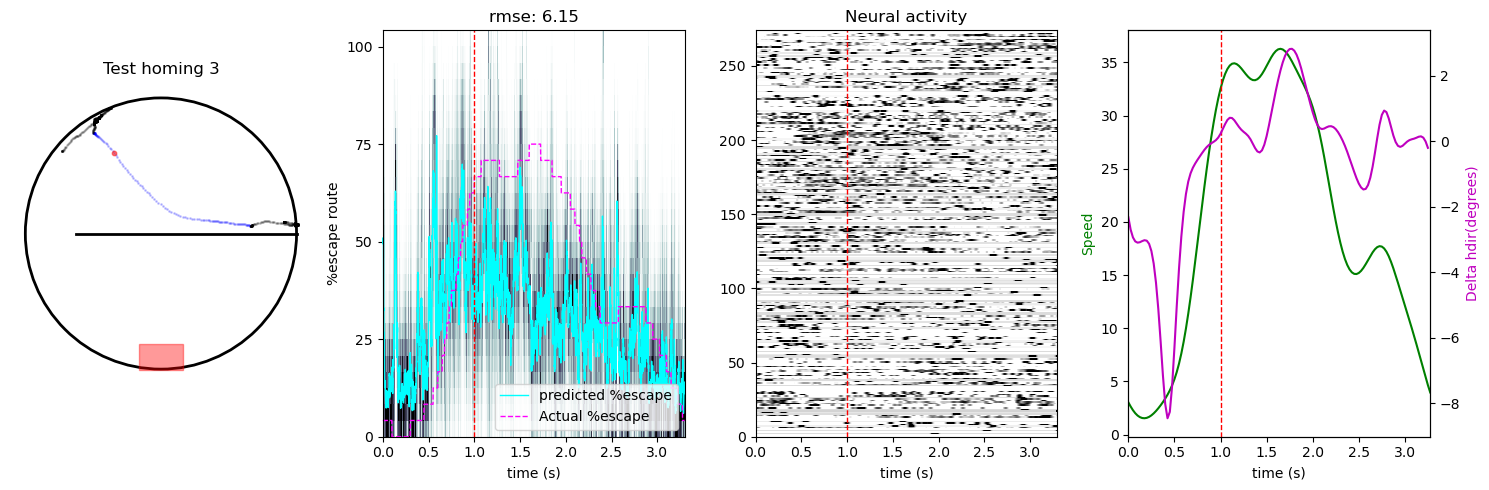

In [217]:
"""Plot for individual test data homings!
Compare behavior to the actual and decoder-predicted fraction of escape route!"""
idx = 3
time_marker = 1 # seconds

fig, ax = plt.subplots(1, 4, figsize = (15, 5))
axs = ax[0]
trajectory_plot(axs, vdf['mouse_x_position'].to_numpy()[test_frame_onsets[idx]:test_frame_offsets[idx]],
                vdf['mouse_y_position'].to_numpy()[test_frame_onsets[idx]:test_frame_offsets[idx]], settings['replay_test_condition'], settings['barrier_test_location'])
axs.scatter(vdf['mouse_x_position'].to_numpy()[test_frame_offsets[idx]:test_frame_offsets[idx]+400],
            vdf['mouse_y_position'].to_numpy()[test_frame_offsets[idx]:test_frame_offsets[idx]+400], s=1, color='k', alpha = 0.2) # to show where the mouse went after the homing period
axs.scatter(vdf['mouse_x_position'].to_numpy()[test_frame_onsets[idx]-400:test_frame_onsets[idx]],
            vdf['mouse_y_position'].to_numpy()[test_frame_onsets[idx]-400:test_frame_onsets[idx]], s=1, color='k', alpha = 0.2) # to show where the mouse went after the homing period
axs.scatter(vdf['mouse_x_position'].to_numpy()[test_frame_onsets[idx]+int(40*time_marker)],
            vdf['mouse_y_position'].to_numpy()[test_frame_onsets[idx]+int(40*time_marker)], s=10, color='r', alpha = 0.5) # to show where the mouse went after the homing period
axs.set_title(f"Test homing {idx}")

axs = ax[1]
test_time_slice = test_time[test_position_onsets[idx]:test_position_offsets[idx]] - test_time[test_position_onsets[idx]]
axs.imshow(test_res[test_position_onsets[idx]:test_position_offsets[idx], :].T, aspect='auto', origin='lower', cmap='bone_r', vmin=0, vmax=.2,
           extent=[test_time_slice[0], test_time_slice[-1], 0, test_res.shape[1]], interpolation='none')
axs.plot(test_time_slice, 
         test_predicted[test_position_onsets[idx]:test_position_offsets[idx]], color="cyan", linestyle="-", linewidth=1, clip_on=False,
         label = r"predicted %escape")
axs.plot(test_time_slice, # so that it starts at 0! 
         data['test_position'][test_position_onsets[idx]:test_position_offsets[idx]], color="magenta", linestyle="--", linewidth=1, clip_on=False,
         label = r"Actual %escape")
axs.axvline(x=time_marker, color='r', linestyle='--', linewidth=1)
axs.set_ylabel(r'%escape route')
axs.set_yticks(np.arange(0, test_res.shape[1]+1,test_res.shape[1]//4))
axs.set_yticklabels(np.arange(0, 101, 25))
axs.set_xlabel('time (s)')
axs.set_title(f"rmse: {test_rmse[idx]:.2f}")
axs.legend(loc='lower right')

axs = ax[2]
rates = gaussian_smooth_rates(data['test_spikes'][test_position_onsets[idx]:test_position_offsets[idx], data['template_seq']],
                              sigma_ms=20, bin_ms=1.0, edge_mode="trim", trim_sigma=3.0,)
z_rates = zscore(rates, axis=0)
axs.imshow(z_rates.T, aspect='auto', origin='lower', cmap='gray_r', vmin = -.5, vmax = 2,
           extent=[test_time_slice[0], test_time_slice[-1], 0, data['test_spikes'].shape[1]], interpolation='none')
axs.axvline(x=time_marker, color='r', linestyle='--', linewidth=1)
axs.set_xlabel('time (s)')
axs.set_title('Neural activity')

axs = ax[3]
time = np.arange(len(vdf['hdir'].to_numpy()[test_frame_onsets[idx]:test_frame_offsets[idx]])) / 40
axs.plot(time, vdf['speed'].to_numpy()[test_frame_onsets[idx]:test_frame_offsets[idx]], color='g') 
axs.axvline(x=time_marker, color='r', linestyle='--', linewidth=1) 
axs.set_xlabel('time (s)') 
axs.set_ylabel('Speed', color = 'g') 
axs.set_xlim(0, time[-1])
axs2 = axs.twinx()
axs2.plot(time[:-1], np.diff(np.rad2deg(vdf['hdir'].to_numpy()[test_frame_onsets[idx]:test_frame_offsets[idx]])), color='m')
axs2.set_ylabel('Delta hdir(degrees)', color='m')

fig.tight_layout()

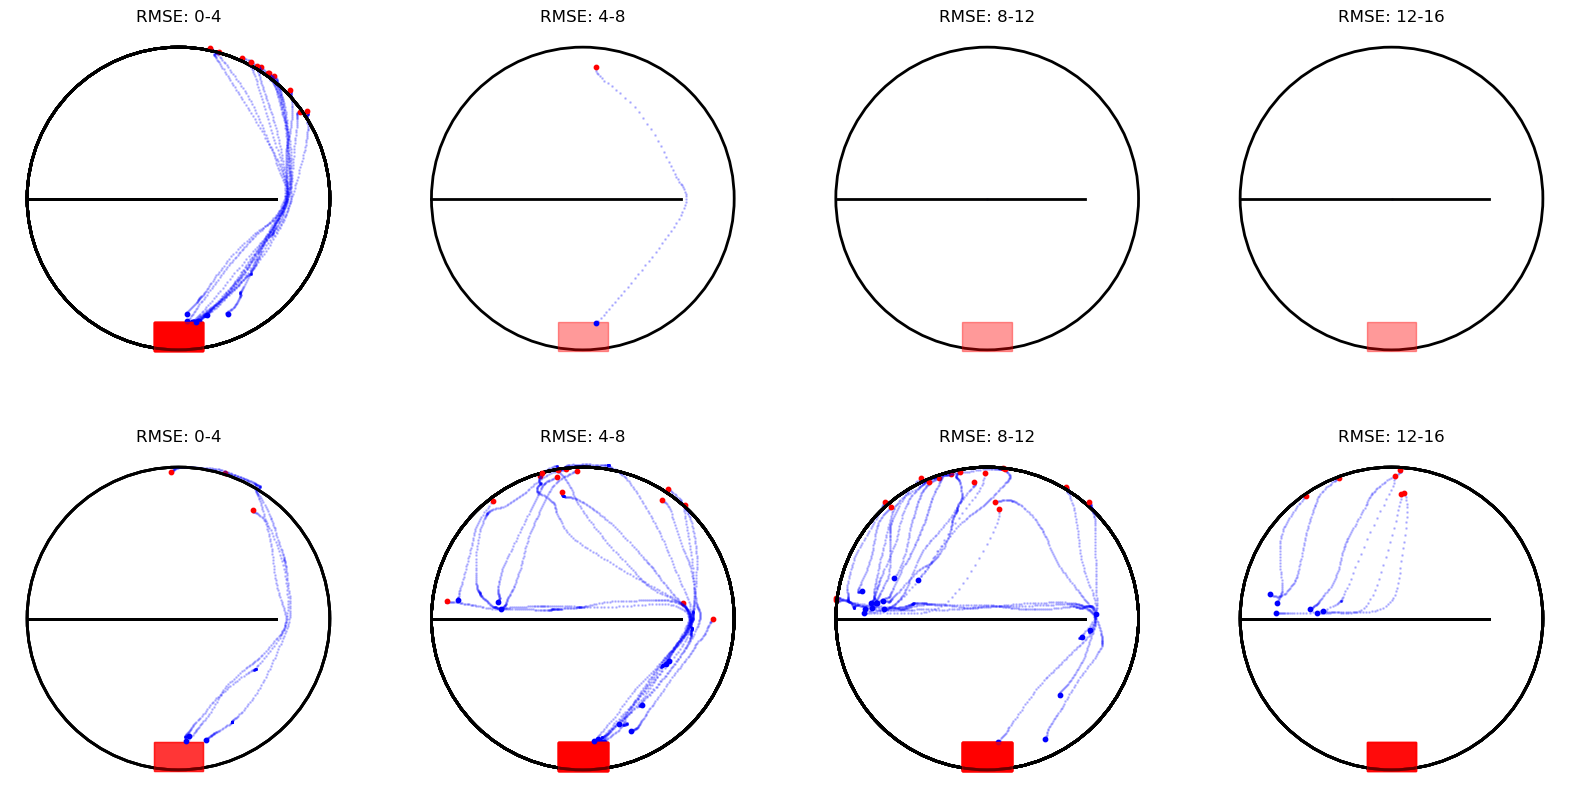

In [438]:
"""Look at homing behavior for different RMSE values"""
rmse_thresholds = [0, 4, 8, 12, 16]

fig, axs = plt.subplots(2, len(rmse_thresholds)-1, figsize=(5*(len(rmse_thresholds)-1), 10))
for t in range(len(rmse_thresholds)-1):
    # plot train behavior
    idx = np.where((train_rmse >= rmse_thresholds[t]) & (train_rmse < rmse_thresholds[t+1]))[0]

    axs[0, t].set_title(f"RMSE: {rmse_thresholds[t]}-{rmse_thresholds[t+1]}")
    for i in idx:
        trajectory_plot(axs[0, t], vdf['mouse_x_position'].to_numpy()[train_frame_onsets[i]:train_frame_offsets[i]],
                        vdf['mouse_y_position'].to_numpy()[train_frame_onsets[i]:train_frame_offsets[i]], settings['replay_train_condition'], settings['barrier_train_location'])
        axs[0, t].scatter(vdf['mouse_x_position'].to_numpy()[train_frame_onsets[i]], 
                       vdf['mouse_y_position'].to_numpy()[train_frame_onsets[i]], color='red', s=10)
        axs[0, t].scatter(vdf['mouse_x_position'].to_numpy()[train_frame_offsets[i]], 
                       vdf['mouse_y_position'].to_numpy()[train_frame_offsets[i]], color='blue', s=10)
    if len(idx) == 0:
        trajectory_plot(axs[0, t], [512,512], [512,512], settings['replay_train_condition'], settings['barrier_train_location'])

    # plot test behavior
    idx = np.where((test_rmse >= rmse_thresholds[t]) & (test_rmse < rmse_thresholds[t+1]))[0]

    axs[1, t].set_title(f"RMSE: {rmse_thresholds[t]}-{rmse_thresholds[t+1]}")
    for i in idx:
        trajectory_plot(axs[1, t], vdf['mouse_x_position'].to_numpy()[test_frame_onsets[i]:test_frame_offsets[i]],
                        vdf['mouse_y_position'].to_numpy()[test_frame_onsets[i]:test_frame_offsets[i]], settings['replay_test_condition'], settings['barrier_test_location'])
        axs[1, t].scatter(vdf['mouse_x_position'].to_numpy()[test_frame_onsets[i]], 
                       vdf['mouse_y_position'].to_numpy()[test_frame_onsets[i]], color='red', s=10)
        axs[1, t].scatter(vdf['mouse_x_position'].to_numpy()[test_frame_offsets[i]], 
                       vdf['mouse_y_position'].to_numpy()[test_frame_offsets[i]], color='blue', s=10)
    if len(idx) == 0:
        trajectory_plot(axs[1, t], [512,512], [512,512], settings['replay_test_condition'], settings['barrier_test_location'])

In [ ]:
"""Look at the actual and decoder tuning curves"""
# TODO: need to load the tuning curves!!
# g = (decoder.place_fields_ * sampling_frequency).plot(
#         x="position", col="neuron", col_wrap=5, color="red", linewidth=2, alpha=0.9, zorder=1, label="Predicted")
# g.axes[0, 0].set_ylabel("Firing Rate [spikes/s]")
# for ax, place_field in zip(g.axes.flat, tuning_curves):
#     ax.plot(np.arange(25), place_field, linewidth=2, color="black", zorder=-1, label="True")
# sns.despine()